# Feature Engineering с Shapley Values для анализа кластеров

### Загружаем результаты кластеризации

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import gc
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import shap
warnings.filterwarnings('ignore')

with open('data/clustering_results.pkl', 'rb') as f:
    clustering_results = pickle.load(f)

cluster_df = clustering_results['cluster_df']
print(f"Загружено пациентов: {len(cluster_df)}")
print(f"Распределение по кластерам:")
print(cluster_df['cluster'].value_counts().sort_index())

# Загружаем подготовленные данные для временных рядов
with open('data/ts_prepared_data.pkl', 'rb') as f:
    ts_data = pickle.load(f)

# Загружаем финальный ML датасет
ml_df = pd.read_csv('data/ml_dataset_ready.csv')
print(f"\nЗагружено ML признаков: {ml_df.shape}")

# Создаем словарь для сопоставления patient_id
ml_df['patient_id'] = ml_df['patient_id'].astype(str)
cluster_df['patient_id'] = cluster_df['patient_id'].astype(str)

# Объединяем с кластерами
ml_with_clusters = ml_df.merge(
    cluster_df[['patient_id', 'cluster']], 
    on='patient_id', 
    how='inner'
)

print(f"\nПосле объединения: {len(ml_with_clusters)} пациентов")
print(f"Распределение кластеров в ML датасете:")
print(ml_with_clusters['cluster'].value_counts().sort_index())

Загружено пациентов: 7389
Распределение по кластерам:
cluster
1     815
2    4200
3    2374
Name: count, dtype: int64

Загружено ML признаков: (9642, 30)

После объединения: 7372 пациентов
Распределение кластеров в ML датасете:
cluster
1     811
2    4190
3    2371
Name: count, dtype: int64


### СОЗДАНИЕ ДОПОЛНИТЕЛЬНЫХ ПРИЗНАКОВ

In [3]:
# Загружаем дневные статистики для более детальных признаков
daily_stats = ts_data['daily_stats']

# Создаем признаки для каждого пациента
patient_features = []

for patient_id in ml_with_clusters['patient_id'].unique():
    patient_data = daily_stats[daily_stats['id пациента'].astype(str) == patient_id]
    
    if len(patient_data) > 0:
        features = {'patient_id': patient_id}
        
        # 1. Вариабельность АД (клинически важный признак)
        features['sbp_variability'] = patient_data['САД'].std()
        features['dbp_variability'] = patient_data['ДАД'].std()
        features['pp_variability'] = patient_data['пульсовое_давление'].std() if 'пульсовое_давление' in patient_data.columns else (patient_data['САД'] - patient_data['ДАД']).std()
        
        # 2. Скорость изменения АД (тренды)
        if len(patient_data) >= 3:
            days = np.arange(len(patient_data))
            slope_sbp = np.polyfit(days, patient_data['САД'].values, 1)[0]
            features['sbp_trend'] = slope_sbp
            
            slope_dbp = np.polyfit(days, patient_data['ДАД'].values, 1)[0]
            features['dbp_trend'] = slope_dbp
        else:
            features['sbp_trend'] = 0
            features['dbp_trend'] = 0
        
        # 3. Процент времени с повышенным АД (САД > 140 или ДАД > 90)
        high_bp = ((patient_data['САД'] > 140) | (patient_data['ДАД'] > 90)).mean()
        features['pct_hypertension'] = high_bp * 100
        
        # 4. Процент времени с низким АД (САД < 90 или ДАД < 60)
        low_bp = ((patient_data['САД'] < 90) | (patient_data['ДАД'] < 60)).mean()
        features['pct_hypotension'] = low_bp * 100
        
        # 5. Коэффициент вариации (стабильность)
        features['sbp_cv'] = (patient_data['САД'].std() / patient_data['САД'].mean()) * 100 if patient_data['САД'].mean() > 0 else 0
        features['dbp_cv'] = (patient_data['ДАД'].std() / patient_data['ДАД'].mean()) * 100 if patient_data['ДАД'].mean() > 0 else 0
        
        # 6. Экстремальные значения
        features['sbp_extreme_high_pct'] = (patient_data['САД'] > 180).mean() * 100
        features['sbp_extreme_low_pct'] = (patient_data['САД'] < 100).mean() * 100
        
        patient_features.append(features)

# Создаем датафрейм с новыми признаками
additional_features = pd.DataFrame(patient_features)

print(f"\nСоздано дополнительных признаков: {len(additional_features.columns) - 1}")
print(f"Дополнительные признаки:\n{additional_features.columns.tolist()}")

# Объединяем с основным ML датасетом
ml_with_clusters = ml_with_clusters.merge(additional_features, on='patient_id', how='left')

print(f"\nИтоговый датасет: {ml_with_clusters.shape}")


Создано дополнительных признаков: 11
Дополнительные признаки:
['patient_id', 'sbp_variability', 'dbp_variability', 'pp_variability', 'sbp_trend', 'dbp_trend', 'pct_hypertension', 'pct_hypotension', 'sbp_cv', 'dbp_cv', 'sbp_extreme_high_pct', 'sbp_extreme_low_pct']

Итоговый датасет: (7372, 42)


### ПОДГОТОВКА ДАННЫХ

In [4]:
# Определяем целевую переменную
target = ml_with_clusters['cluster'].values

# ВРЕМЕННЫЕ ПРИЗНАКИ - ИСКЛЮЧАЕМ (уже учтены в GDTW!)
temporal_features = ['время измерения', 'время измерения_days_diff']

# ИСКЛЮЧАЕМ ГРУППУ НАБЛЮДЕНИЯ И ЧАСОВОЙ ПОЯС ИЗ ГРАФИКОВ
exclude_from_plots = ['группа наблюдения', 'часовой пояс']

# Определяем все признаки для модели
exclude_cols = ['patient_id', 'cluster', 'kzs_count', 'target_high_risk', 'target_risk_category'] + temporal_features
feature_cols = [col for col in ml_with_clusters.columns if col not in exclude_cols]
for feat in temporal_features:
    print(f"  - {feat}")
for feat in exclude_from_plots:
    print(f"  - {feat}")
for feat in feature_cols[:15]:
    print(f"  - {feat}")

# Создаем копию для работы
df_model = ml_with_clusters[feature_cols].copy()

  - время измерения
  - время измерения_days_diff
  - группа наблюдения
  - часовой пояс
  - возраст
  - рост
  - масса
  - ИМТ
  - часовой пояс
  - группа наблюдения
  - САД_mean
  - САД_std
  - САД_min
  - САД_max
  - САД_median
  - САД_iqr
  - ДАД_mean
  - ДАД_std
  - ДАД_min


In [5]:
# Кодируем категориальные признаки
from sklearn.preprocessing import LabelEncoder

for col in df_model.columns:
    if df_model[col].dtype == 'object' or df_model[col].dtype == 'str' or df_model[col].dtype.name == 'string':
        print(f"\nКодируем признак: {col}")
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))

non_numeric = []
for col in df_model.columns:
    if not pd.api.types.is_numeric_dtype(df_model[col]):
        non_numeric.append(col)
        print(f"  x {col}: {df_model[col].dtype}")
    else:
        print(f"  ✓ {col}: {df_model[col].dtype}")

if non_numeric:
    for col in non_numeric:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
        print(f"  Принудительно преобразован {col}")
else:
    print("\nВсе колонки числовые!")

# Обработка пропусков
print("\nОбработка пропусков...")
for col in df_model.columns:
    if df_model[col].isnull().any():
        median_val = df_model[col].median()
        df_model[col].fillna(median_val, inplace=True)
        print(f"  {col}: заполнено медианой {median_val:.2f}")

print(f"\nПропуски после обработки: {df_model.isnull().sum().sum()}")

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)
X = pd.DataFrame(X_scaled, columns=df_model.columns)
y = target

print(f"\nМатрица признаков: {X.shape}")
print(f"Распределение кластеров: {np.bincount(y)}")


Кодируем признак: группа наблюдения
  ✓ возраст: float64
  ✓ рост: float64
  ✓ масса: float64
  ✓ ИМТ: float64
  ✓ часовой пояс: int64
  ✓ группа наблюдения: int64
  ✓ САД_mean: float64
  ✓ САД_std: float64
  ✓ САД_min: int64
  ✓ САД_max: int64
  ✓ САД_median: float64
  ✓ САД_iqr: float64
  ✓ ДАД_mean: float64
  ✓ ДАД_std: float64
  ✓ ДАД_min: int64
  ✓ ДАД_max: int64
  ✓ ДАД_median: float64
  ✓ ЧП_mean: float64
  ✓ ЧП_std: float64
  ✓ ЧП_min: int64
  ✓ ЧП_max: int64
  ✓ ЧП_median: float64
  ✓ пульсовое_давление_mean: float64
  ✓ пульсовое_давление_std: float64
  ✓ sbp_variability: float64
  ✓ dbp_variability: float64
  ✓ pp_variability: float64
  ✓ sbp_trend: float64
  ✓ dbp_trend: float64
  ✓ pct_hypertension: float64
  ✓ pct_hypotension: float64
  ✓ sbp_cv: float64
  ✓ dbp_cv: float64
  ✓ sbp_extreme_high_pct: float64
  ✓ sbp_extreme_low_pct: float64

Все колонки числовые!

Обработка пропусков...

Пропуски после обработки: 0

Матрица признаков: (7372, 35)
Распределение кластеров: [

### ОБУЧЕНИЕ МОДЕЛИ

In [6]:
# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Обучение модели
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Оценка
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nТочность модели: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[f'Cluster_{i}' for i in range(1, 4)]))

# Кросс-валидация
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': df_model.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("ТОП-15 ВАЖНЫХ ПРИЗНАКОВ")
for idx, row in feature_importance.head(15).iterrows():
    print(f"  {row['feature']:<30}: {row['importance']:.4f}")

Train: (5897, 35), Test: (1475, 35)

Точность модели: 0.6271

Classification Report:
              precision    recall  f1-score   support

   Cluster_1       0.50      0.03      0.06       162
   Cluster_2       0.67      0.88      0.76       838
   Cluster_3       0.51      0.39      0.44       475

    accuracy                           0.63      1475
   macro avg       0.56      0.43      0.42      1475
weighted avg       0.60      0.63      0.58      1475


Cross-validation scores: [0.63932203 0.6359322  0.62211669 0.62550882 0.63161465]
Mean CV accuracy: 0.6309 (+/- 0.0127)
ТОП-15 ВАЖНЫХ ПРИЗНАКОВ
  dbp_trend                     : 0.1966
  sbp_trend                     : 0.1941
  САД_min                       : 0.0533
  САД_max                       : 0.0480
  ЧП_max                        : 0.0388
  ДАД_min                       : 0.0365
  ДАД_max                       : 0.0293
  ЧП_min                        : 0.0290
  группа наблюдения             : 0.0274
  dbp_cv            

### SHAP ANALYSIS

SHAP значения вычислены для 1000 образцов
Форма shap_values: (1000, 35, 3)

Топ-10 признаков по SHAP:
          feature  mean_abs_shap
        sbp_trend       0.040346
        dbp_trend       0.039481
          САД_min       0.019414
          САД_max       0.018707
           ЧП_max       0.013623
группа наблюдения       0.011869
           ЧП_min       0.010767
          ДАД_min       0.010562
          ДАД_max       0.010394
     часовой пояс       0.008014


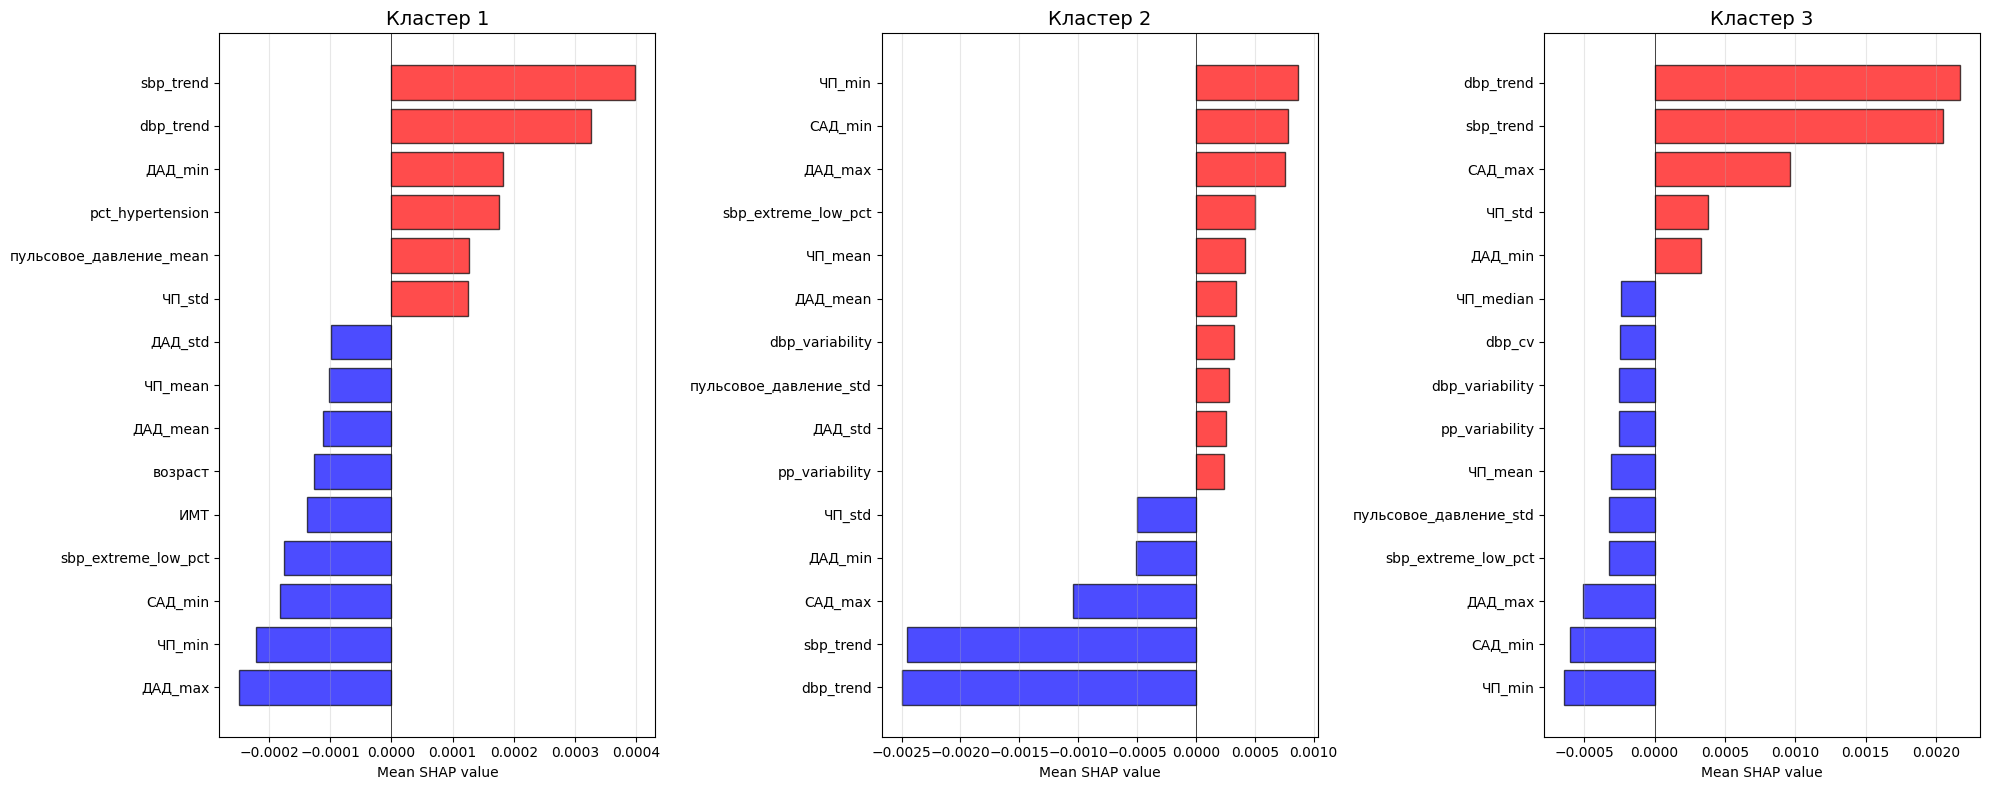

Сохранено: data/photo/shap_cluster_importance_clean.png


In [7]:
# Создаем explainer
explainer = shap.TreeExplainer(rf_model)

# Берем выборку для SHAP
sample_size = min(1000, len(X_test))
X_test_sample = X_test[:sample_size]
shap_values = explainer.shap_values(X_test_sample)

print(f"SHAP значения вычислены для {sample_size} образцов")
print(f"Форма shap_values: {shap_values.shape}")

# Вычисляем глобальную важность
n_samples, n_features, n_classes = shap_values.shape
mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 2))

shap_importance = pd.DataFrame({
    'feature': df_model.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print(f"\nТоп-10 признаков по SHAP:")
print(shap_importance.head(10).to_string(index=False))

# Bar plots для каждого кластера - ИСКЛЮЧАЕМ ГРУППУ НАБЛЮДЕНИЯ И ЧАСОВОЙ ПОЯС
fig2, axes2 = plt.subplots(1, 3, figsize=(20, 8))

for class_idx in range(n_classes):
    shap_values_class = shap_values[:, :, class_idx]
    mean_shap = np.mean(shap_values_class, axis=0)
    
    # Создаем датафрейм с важностью и исключаем ненужные признаки
    shap_df = pd.DataFrame({
        'feature': df_model.columns,
        'mean_shap': mean_shap
    })
    shap_df = shap_df[~shap_df['feature'].isin(exclude_from_plots)]
    
    # Топ-15 признаков по абсолютной важности
    shap_df['abs_shap'] = np.abs(shap_df['mean_shap'])
    shap_df = shap_df.sort_values('abs_shap', ascending=False).head(15)
    shap_df = shap_df.sort_values('mean_shap', ascending=True)
    
    ax = axes2[class_idx]
    colors = ['red' if x > 0 else 'blue' for x in shap_df['mean_shap']]
    
    ax.barh(range(len(shap_df)), shap_df['mean_shap'], color=colors, alpha=0.7, edgecolor='black')
    ax.set_yticks(range(len(shap_df)))
    ax.set_yticklabels(shap_df['feature'], fontsize=10)
    ax.set_xlabel('Mean SHAP value')
    ax.set_title(f'Кластер {class_idx + 1}', fontsize=14)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('data/photo/shap_cluster_importance_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: data/photo/shap_cluster_importance_clean.png")

### СРАВНЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ ПО КЛАСТЕРАМ

In [8]:
# Анализ для каждого кластера
cluster_interpretation = {}

for class_idx in range(n_classes):
    print(f"\n{'='*50}")
    print(f"КЛАСТЕР {class_idx + 1}")
    print(f"{'='*50}")
    
    shap_values_class = shap_values[:, :, class_idx]
    mean_shap = np.mean(shap_values_class, axis=0)
    
    # Создаем датафрейм и исключаем ненужные признаки
    shap_df = pd.DataFrame({
        'feature': df_model.columns,
        'mean_shap': mean_shap
    })
    shap_df = shap_df[~shap_df['feature'].isin(exclude_from_plots)]
    
    # Топ-5 положительных (увеличивают вероятность)
    positive = shap_df[shap_df['mean_shap'] > 0].sort_values('mean_shap', ascending=False).head(5)
    # Топ-5 отрицательных (уменьшают вероятность)
    negative = shap_df[shap_df['mean_shap'] < 0].sort_values('mean_shap', ascending=True).head(5)
    
    print(f"\nПризнаки, увеличивающие вероятность:")
    for _, row in positive.iterrows():
        print(f"  + {row['feature']}: {row['mean_shap']:.4f}")
    
    print(f"\nПризнаки, уменьшающие вероятность:")
    for _, row in negative.iterrows():
        print(f"  - {row['feature']}: {row['mean_shap']:.4f}")
    
    cluster_interpretation[class_idx + 1] = {
        'increasing': positive['feature'].tolist(),
        'decreasing': negative['feature'].tolist()
    }


КЛАСТЕР 1

Признаки, увеличивающие вероятность:
  + sbp_trend: 0.0004
  + dbp_trend: 0.0003
  + ДАД_min: 0.0002
  + pct_hypertension: 0.0002
  + пульсовое_давление_mean: 0.0001

Признаки, уменьшающие вероятность:
  - ДАД_max: -0.0002
  - ЧП_min: -0.0002
  - САД_min: -0.0002
  - sbp_extreme_low_pct: -0.0002
  - ИМТ: -0.0001

КЛАСТЕР 2

Признаки, увеличивающие вероятность:
  + ЧП_min: 0.0009
  + САД_min: 0.0008
  + ДАД_max: 0.0008
  + sbp_extreme_low_pct: 0.0005
  + ЧП_mean: 0.0004

Признаки, уменьшающие вероятность:
  - dbp_trend: -0.0025
  - sbp_trend: -0.0025
  - САД_max: -0.0010
  - ДАД_min: -0.0005
  - ЧП_std: -0.0005

КЛАСТЕР 3

Признаки, увеличивающие вероятность:
  + dbp_trend: 0.0022
  + sbp_trend: 0.0021
  + САД_max: 0.0010
  + ЧП_std: 0.0004
  + ДАД_min: 0.0003

Признаки, уменьшающие вероятность:
  - ЧП_min: -0.0006
  - САД_min: -0.0006
  - ДАД_max: -0.0005
  - sbp_extreme_low_pct: -0.0003
  - пульсовое_давление_std: -0.0003


### КЛИНИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ

In [9]:
print("\nКЛАСТЕР 1 (ВЫСОКИЙ РИСК):")
print("   Характеристики:")
if 1 in cluster_interpretation:
    inc = cluster_interpretation[1]['increasing']
    dec = cluster_interpretation[1]['decreasing']
    if 'sbp_trend' in inc:
        print("   - Положительный тренд САД (давление повышается)")
    if 'dbp_trend' in inc:
        print("   - Положительный тренд ДАД")
    if 'pct_hypertension' in inc:
        print("   - Высокий процент времени с гипертонией")
    if 'sbp_variability' in inc:
        print("   - Высокая вариабельность давления")
    print("\n   Клинические рекомендации:")
    print("   - Требуют наиболее интенсивного мониторинга")
    print("   - Необходима коррекция антигипертензивной терапии")
    print("   - Риск сердечно-сосудистых осложнений повышен")

print("\nКЛАСТЕР 2 (СРЕДНИЙ РИСК):")
print("   Характеристики:")
if 2 in cluster_interpretation:
    inc = cluster_interpretation[2]['increasing']
    dec = cluster_interpretation[2]['decreasing']
    if 'sbp_trend' in dec:
        print("   - Отрицательный тренд САД (давление снижается)")
    if 'dbp_trend' in dec:
        print("   - Отрицательный тренд ДАД")
    if 'pct_hypertension' in dec:
        print("   - Умеренный процент времени с гипертонией")
    print("\n   Клинические рекомендации:")
    print("   - Регулярный мониторинг (1 раз в 2-3 месяца)")
    print("   - Поддержание текущей терапии")
    print("   - Контроль факторов риска")

print("\nКЛАСТЕР 3 (НИЗКИЙ РИСК):")
print("   Характеристики:")
if 3 in cluster_interpretation:
    inc = cluster_interpretation[3]['increasing']
    dec = cluster_interpretation[3]['decreasing']
    if 'sbp_trend' in dec:
        print("   - Стабильные показатели давления")
    if 'pct_hypertension' in dec:
        print("   - Низкий процент времени с гипертонией")
    print("\n   Клинические рекомендации:")
    print("   - Плановое наблюдение (1 раз в 6 месяцев)")
    print("   - Профилактические мероприятия")
    print("   - Образовательные программы по здоровому образу жизни")

# Сохраняем важность признаков
feature_importance.to_csv('data/feature_importance_clean.csv', index=False)
shap_importance.to_csv('data/shap_importance_clean.csv', index=False)

# Сохраняем полный отчет
ml_with_clusters['predicted_cluster'] = rf_model.predict(X)
ml_with_clusters['cluster_1_prob'] = rf_model.predict_proba(X)[:, 0]
ml_with_clusters['cluster_2_prob'] = rf_model.predict_proba(X)[:, 1]
ml_with_clusters['cluster_3_prob'] = rf_model.predict_proba(X)[:, 2]

ml_with_clusters.to_csv('data/clinical_report_clean.csv', index=False)
print("Сохранено: data/clinical_report_clean.csv")

print("\nСОЗДАННЫЕ ФАЙЛЫ:")
print("  - data/clinical_report_clean.csv - полный клинический отчет")
print("  - data/feature_importance_clean.csv - важность признаков (Gini)")
print("  - data/shap_importance_clean.csv - важность признаков (SHAP)")
print("\nСОЗДАННЫЕ ГРАФИКИ:")
print("  - data/photo/shap_cluster_importance_clean.png - важность по кластерам")

# Очистка памяти
gc.collect()


КЛАСТЕР 1 (ВЫСОКИЙ РИСК):
   Характеристики:
   - Положительный тренд САД (давление повышается)
   - Положительный тренд ДАД
   - Высокий процент времени с гипертонией

   Клинические рекомендации:
   - Требуют наиболее интенсивного мониторинга
   - Необходима коррекция антигипертензивной терапии
   - Риск сердечно-сосудистых осложнений повышен

КЛАСТЕР 2 (СРЕДНИЙ РИСК):
   Характеристики:
   - Отрицательный тренд САД (давление снижается)
   - Отрицательный тренд ДАД

   Клинические рекомендации:
   - Регулярный мониторинг (1 раз в 2-3 месяца)
   - Поддержание текущей терапии
   - Контроль факторов риска

КЛАСТЕР 3 (НИЗКИЙ РИСК):
   Характеристики:

   Клинические рекомендации:
   - Плановое наблюдение (1 раз в 6 месяцев)
   - Профилактические мероприятия
   - Образовательные программы по здоровому образу жизни
Сохранено: data/clinical_report_clean.csv

СОЗДАННЫЕ ФАЙЛЫ:
  - data/clinical_report_clean.csv - полный клинический отчет
  - data/feature_importance_clean.csv - важность призн

179